In [33]:
import os
import re
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from scipy.optimize import curve_fit
from astroquery.simbad import Simbad
import matplotlib.patheffects as path_effects

In [34]:
# Any changes made need to made to both SS_1 and SS_2!!

with open("Star_Configurations/Standards_1.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Example access:
print(cfg["main_star"])

UCAC4 754-046742


In [35]:
base_dir = Path(cfg["base_dir"])
print("base_dir = "+str(base_dir))

file_object = cfg["file_object"]
print("file_object = "+str(file_object))

main_star = cfg["main_star"]
print("main_star = "+main_star)

file_nights = cfg["file_nights"].keys()
file_nights = list(file_nights)
print("file_nights = "+str(file_nights))

star_period = cfg["star_period"]
print("star_period = "+str(star_period))

base_dir = data
file_object = Standards_1
main_star = UCAC4 754-046742
file_nights = ['2024_03_05']
star_period = 1.0


In [36]:
colour_list_all = []
for file_night in file_nights:
    colour_list = cfg['file_nights'][str(file_night)]["colour_list"]
    colour_list_all.append(colour_list)
unique_colour_entries = sorted(set(item for sublist in colour_list_all for item in sublist))
print(unique_colour_entries)

['Bader_JC_B', 'Bader_JC_R', 'Bader_JC_U', 'Bader_JC_V', 'ZWO_Blue', 'ZWO_Green', 'ZWO_Red']


# Sorting data

In [37]:
# Load Landolt catalog
landolt_stars = pd.read_csv("data/landolt_north.csv", delimiter="|")
landolt_stars.columns = ['oid', 'main_id', 'ra', 'dec']
landolt_names = set(landolt_stars["main_id"].str.strip())

In [38]:
# Add 'ids' field to SIMBAD queries
Simbad.reset_votable_fields()
Simbad.add_votable_fields("ids")

def get_simbad_aliases(star_name):
    if not isinstance(star_name, str) or star_name.strip() == "":
        return []
    try:
        result = Simbad.query_object(star_name)
        if result is not None and len(result) > 0:
            aliases = result["ids"][0].split(" | ")
            return aliases
        else:
            return []
    except Exception as e:
        print(f"SIMBAD query failed for {star_name}: {e}")
        return []

In [39]:
def read_data(file_path, colour):
    try:
        df = pd.read_csv(file_path, usecols=[
            "Saturated", "matched_id", "matched_MAIN_ID", "Source_Mag_norm", "Source_Mag_Error_norm", "Air mass"
        ])
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return pd.DataFrame()

    # Filter out saturated stars and rows without matched_id
    df = df[(df["Saturated"] != True) & (df["matched_id"].notna())]

    # Rename columns
    df = df.rename(columns={
        "matched_MAIN_ID": "star_name",
        "Source_Mag_norm": "instrumental_mag",
        "Source_Mag_Error_norm": "instrumental_mag_err",
        "Air mass": "air_mass"
    })

    # Create fallback index: use star_name if available, else matched_id
    df["star_index"] = df["star_name"].fillna(df["matched_id"])

    # Add filter info
    df["filter"] = colour

    return df[["star_index", "matched_id", "star_name", "filter", "instrumental_mag", "instrumental_mag_err", "air_mass"]]

In [40]:
# Collect all data
long_data = []

for colour in unique_colour_entries:
    folder = base_dir / file_object / file_nights[0] / "Light" / colour / "photometry_matched_norm"
    for file in os.listdir(folder):
        if file.endswith(".csv"):
            file_path = folder / file
            df = read_data(file_path, colour)
            if not df.empty:
                long_data.append(df)

# Combine all rows
long_df = pd.concat(long_data, ignore_index=True)

# Create lookup table before pivot
lookup = long_df[["star_index", "matched_id", "star_name"]].drop_duplicates()

# Pivot to wide format
stars = long_df.pivot_table(
    index="star_index",
    columns="filter",
    values=["instrumental_mag", "instrumental_mag_err", "air_mass"],
    aggfunc="mean"
)

# Flatten MultiIndex columns
stars.columns = [f"{col[1]}_{col[0]}" for col in stars.columns]
stars = stars.reset_index()

# Merge back matched_id and star_name
stars = stars.merge(lookup, on="star_index", how="left")

In [41]:
stars["simbad_aliases"] = stars["star_name"].apply(get_simbad_aliases)
# Convert alias strings to lists
stars["simbad_aliases"] = stars["simbad_aliases"].apply(
    lambda x: x[0].split("|") if isinstance(x, list) and len(x) > 0 else []
)
# Normalise Landolt names
landolt_names = set(landolt_stars["main_id"].str.strip())

# Check if any Landolt name appears in the aliases list
def is_landolt_alias(alias_list):
    return any(alias.strip() in landolt_names for alias in alias_list)

# Apply to stars
stars["is_landolt_star"] = stars["simbad_aliases"].apply(is_landolt_alias)

In [42]:
def get_simbad_uvbri_magnitudes(star_name):
    if not isinstance(star_name, str) or star_name.strip() == "":
        return {}
    try:
        Simbad.reset_votable_fields()
        Simbad.add_votable_fields("U", "B", "V", "R", "I")

        result = Simbad.query_object(star_name)
        if result is not None and len(result) > 0:
            result_df = result.to_pandas()
            result_df = result_df.apply(lambda col: col.map(lambda x: None if np.ma.is_masked(x) else x))
            row = result_df.iloc[0]
            return {
                "U_mag": row.get("U", None),
                "B_mag": row.get("B", None),
                "V_mag": row.get("V", None),
                "R_mag": row.get("R", None),
                "I_mag": row.get("I", None)
            }
        else:
            return {}
    except Exception as e:
        print(f"SIMBAD magnitude query failed for {star_name}: {e}")
        return {}



def extract_gaia_dr3_id(aliases):
    for alias in aliases:
        match = re.match(r"Gaia DR3 (\d+)", alias.strip())
        if match:
            return match.group(1)
    return None



def get_gaia_magnitudes(gaia_id):
    if gaia_id is None:
        return {}

    try:
        query = f"""
        SELECT phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
        FROM gaiadr3.gaia_source
        WHERE source_id = {gaia_id}
        """
        job = Gaia.launch_job(query)
        result = job.get_results()

        if len(result) > 0:
            row = result[0]
            return {
                "BP_mag": row["phot_bp_mean_mag"],
                "RP_mag": row["phot_rp_mean_mag"],
                "G_mag": row["phot_g_mean_mag"]
            }
        else:
            return {}
    except Exception as e:
        print(f"Gaia query failed for {gaia_id}: {e}")
        return {}

In [43]:

#Query SIMBAD for UVBRI magnitudes
uvbri_data = stars["star_name"].apply(get_simbad_uvbri_magnitudes)

# Convert to DataFrame and merge
uvbri_df = pd.DataFrame(uvbri_data.tolist())
stars = pd.concat([stars, uvbri_df], axis=1)

stars["gaia_dr3_id"] = stars["simbad_aliases"].apply(extract_gaia_dr3_id)

In [44]:

gaia_data = stars["gaia_dr3_id"].apply(get_gaia_magnitudes)
gaia_df = pd.DataFrame(gaia_data.tolist())
stars = pd.concat([stars, gaia_df], axis=1)


In [45]:
#Renaming columns to make reading easier
stars.rename(columns={'Bader_JC_U_instrumental_mag': 'U_ins_mag',
                      'Bader_JC_B_instrumental_mag': 'B_ins_mag',
                      'Bader_JC_V_instrumental_mag': 'V_ins_mag',
                      'Bader_JC_R_instrumental_mag': 'R_ins_mag',

                      'Bader_JC_U_instrumental_mag_err' : 'U_ins_mag_err',
                      'Bader_JC_B_instrumental_mag_err' : 'B_ins_mag_err',
                      'Bader_JC_V_instrumental_mag_err' : 'V_ins_mag_err',
                      'Bader_JC_R_instrumental_mag_err' : 'R_ins_mag_err',
                      
                      'Bader_JC_U_air_mass' : 'U_air_mass',
                      'Bader_JC_B_air_mass' : 'B_air_mass',
                      'Bader_JC_V_air_mass' : 'V_air_mass',
                      'Bader_JC_R_air_mass' : 'R_air_mass',
                      
                      'ZWO_Blue_instrumental_mag': 'ZWO_Blue_ins_mag',
                      'ZWO_Green_instrumental_mag': 'ZWO_Green_ins_mag',
                      'ZWO_Red_instrumental_mag': 'ZWO_Red_ins_mag',
                      
                      'ZWO_Blue_instrumental_mag_err' : 'ZWO_Blue_ins_mag_err',
                      'ZWO_Green_instrumental_mag_err' : 'ZWO_Green_ins_mag_err',
                      'ZWO_Red_instrumental_mag_err' : 'ZWO_Red_ins_mag_err'}, inplace=True)

In [46]:
stars.to_csv(f"data/{file_object}_stars_data.csv", index=False)

# Filter Transforms

In [47]:
# Load both standards files
files = ["Standards_1_stars_data.csv", "Standards_2_stars_data.csv"]

# Read and concatenate
standards_dfs = [pd.read_csv(base_dir / f) for f in files]
stars = pd.concat(standards_dfs, ignore_index=True)

In [48]:
# Eq for filter transformation:

def model(inputs, a, b, c):
    x_mag, airmass, colour = inputs
    return x_mag + a + b * airmass + c * colour


In [59]:
def filter_transform(from_filter, to_filter, plot=False):
    # Prepare raw arrays
    x_mag = stars[f"{from_filter}_ins_mag"].values
    x_err = stars[f"{from_filter}_ins_mag_err"].values
    
    y_mag = stars[f"{to_filter}_ins_mag"].values
    y_err = stars[f"{to_filter}_ins_mag_err"].values

    airmass = stars[f"{from_filter}_air_mass"].values
    
    colour = stars["colour"].values
    colour_err = stars["colour_err"].values

    # Filtering: ensure all inputs and errors are finite
    valid_mask = (
        np.isfinite(x_mag) &
        np.isfinite(x_err) &
        np.isfinite(airmass) &
        np.isfinite(colour) &
        np.isfinite(colour_err) &
        np.isfinite(y_mag) &
        np.isfinite(y_err)
    )

    # Apply mask and clean arrays
    x_mag_clean = x_mag[valid_mask]
    x_err_clean = np.abs(x_err[valid_mask])
    airmass_clean = airmass[valid_mask]
    colour_clean = colour[valid_mask]
    colour_err_clean = np.abs(colour_err[valid_mask])
    y_mag_clean = y_mag[valid_mask]
    y_err_clean = np.abs(y_err[valid_mask])
    inputs_clean = (x_mag_clean, airmass_clean, colour_clean)

    # Combine errors for weighting (including colour error)
    total_err_clean = np.sqrt(x_err_clean**2 + y_err_clean**2 + colour_err_clean**2)

    # Fit the model with weights
    params, covariance = curve_fit(
        model,
        inputs_clean,
        y_mag_clean,
        p0=[1, 1, 1],
        sigma=total_err_clean,
        absolute_sigma=True
    )

    a_fit, b_fit, c_fit = params
    a_err, b_err, c_err = np.sqrt(np.diag(covariance))

    # --- χ² calculation ---
    y_pred = model(inputs_clean, *params)
    residuals = y_mag_clean - y_pred
    chi2 = np.sum((residuals / total_err_clean)**2)
    dof = len(y_mag_clean) - len(params)   # degrees of freedom
    reduced_chi2 = chi2 / dof if dof > 0 else np.nan

    if plot:
        # Plot fit
        rhs = x_mag_clean + a_fit + b_fit * airmass_clean + c_fit * colour_clean
        lhs = y_mag_clean

        plt.figure(figsize=(8, 5))
        plt.errorbar(rhs, lhs, xerr=total_err_clean, yerr=y_err_clean,
                     fmt='o', capsize=3, label='Data with errors')
        plt.plot(rhs, y_pred, 'r-', label='Fitted Line')
        plt.title(f"Filter Model Fit: {from_filter} -> JC_{to_filter}\nchi^2 = {chi2:.2f}, reduced chi^2 = {reduced_chi2:.2f}")
        plt.xlabel(f"Predicted magnitude: {from_filter} + a + (b × airmass) + (c × colour)")
        plt.ylabel(f"Measured magnitude in JC {to_filter}")
        plt.legend()
        plt.grid(True)
        plt.gca().invert_xaxis()
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # Residuals plot
        delta_mag = residuals
        plt.figure(figsize=(8, 5))
        plt.errorbar(y_mag_clean, delta_mag, xerr=y_err_clean, yerr=total_err_clean,
                     fmt='o', capsize=3, label='Residuals')
        plt.axhline(0, color='r', linestyle='--', label='Zero residual')
        plt.title(f"Residuals: {from_filter} -> JC_{to_filter}")
        plt.xlabel(f"Measured magnitude in JC {to_filter}")
        plt.ylabel("Residual (measured − predicted)")
        plt.legend()
        plt.grid(True)
        plt.gca().invert_xaxis()
        plt.tight_layout()
        plt.show()

    print(f"Fitted parameters:\n"
          f"a = {a_fit:.4f} ± {a_err:.4f}, "
          f"b = {b_fit:.4f} ± {b_err:.4f}, "
          f"c = {c_fit:.4f} ± {c_err:.4f}, "
          f"chi^2 = {chi2:.2f}, reduced chi^2 = {reduced_chi2:.2f}\n")

    return a_fit, b_fit, c_fit, a_err, b_err, c_err, chi2, reduced_chi2

In [60]:
def compute_colour(df, m1, m2):
    df['colour'] = df[f'{m1}_ins_mag'] - df[f'{m2}_ins_mag']
    df['colour_err'] = np.sqrt(
        df[f'{m1}_ins_mag_err']**2 + df[f'{m2}_ins_mag_err']**2
    )
    return df

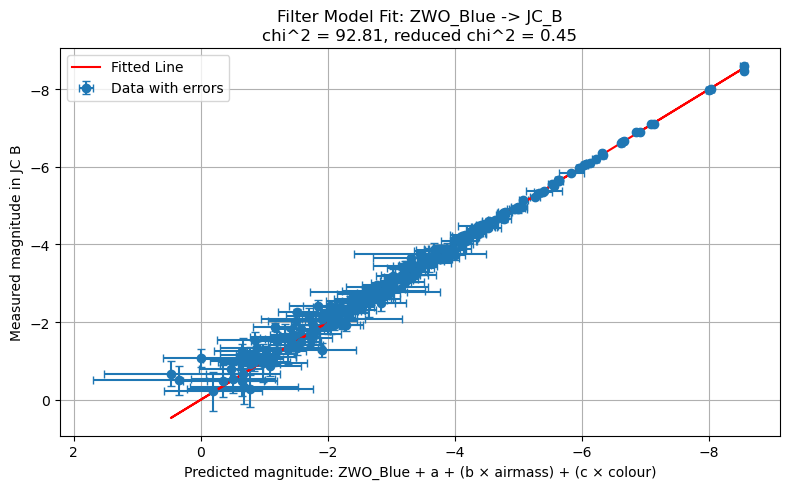

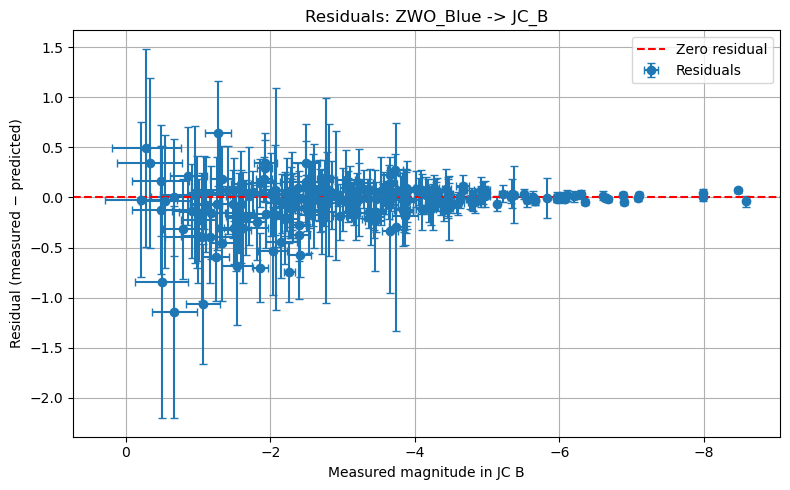

Fitted parameters:
a = 1.1661 ± 0.0496, b = -0.3974 ± 0.0375, c = 0.1766 ± 0.0464, chi^2 = 92.81, reduced chi^2 = 0.45



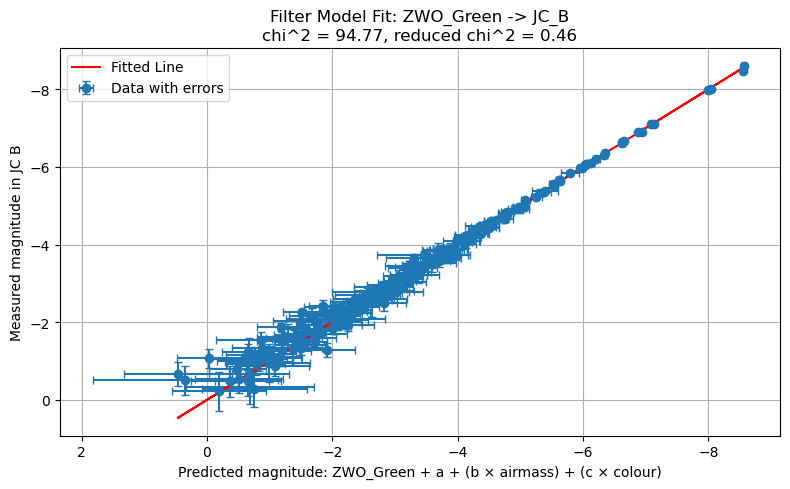

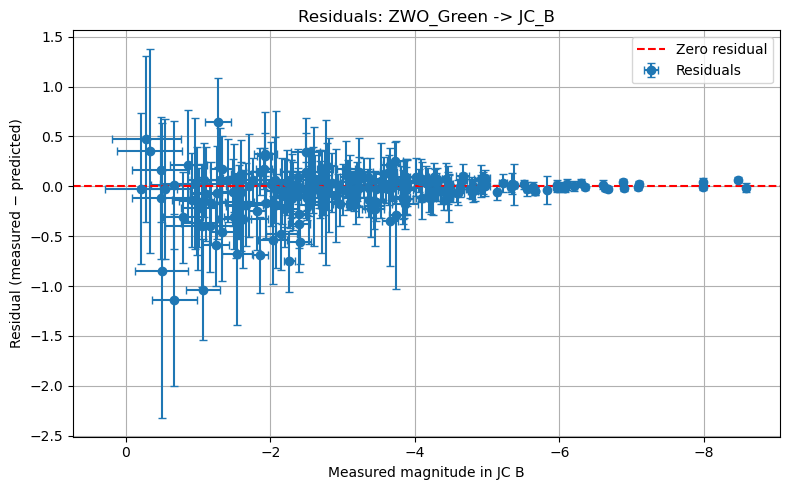

Fitted parameters:
a = 1.1270 ± 0.0443, b = -0.3572 ± 0.0323, c = 1.1706 ± 0.0444, chi^2 = 94.77, reduced chi^2 = 0.46



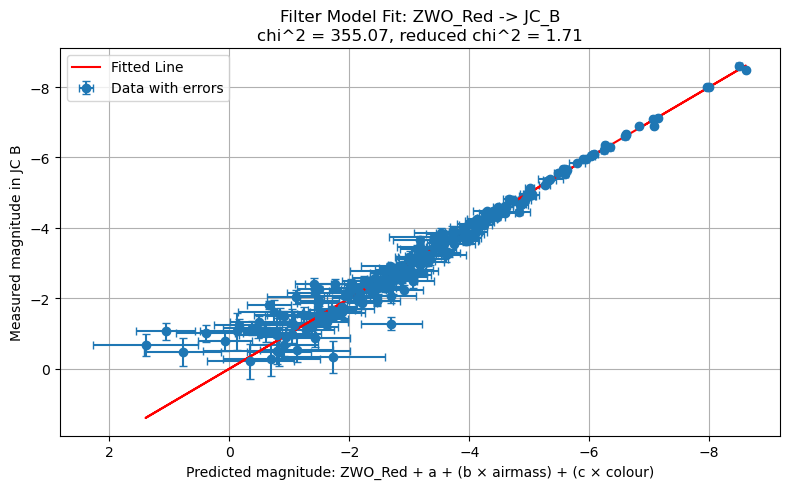

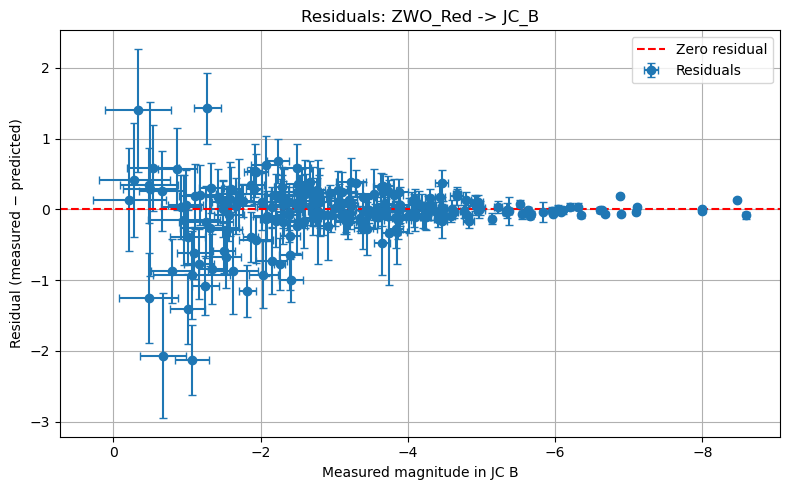

Fitted parameters:
a = 1.3231 ± 0.0473, b = -0.6875 ± 0.0349, c = 2.0914 ± 0.0467, chi^2 = 355.07, reduced chi^2 = 1.71



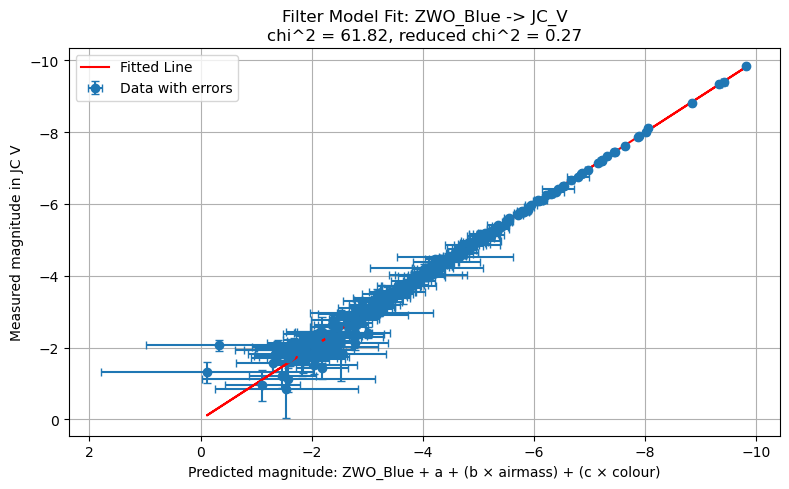

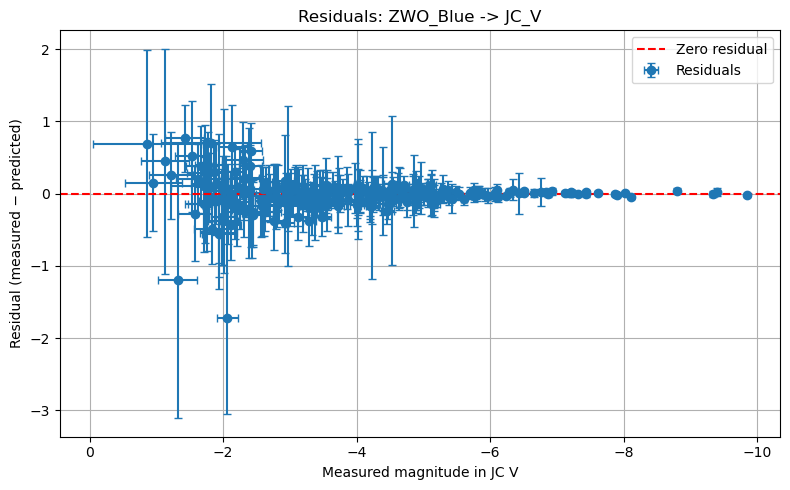

Fitted parameters:
a = -0.1739 ± 0.0446, b = 0.0319 ± 0.0336, c = -1.0894 ± 0.0403, chi^2 = 61.82, reduced chi^2 = 0.27



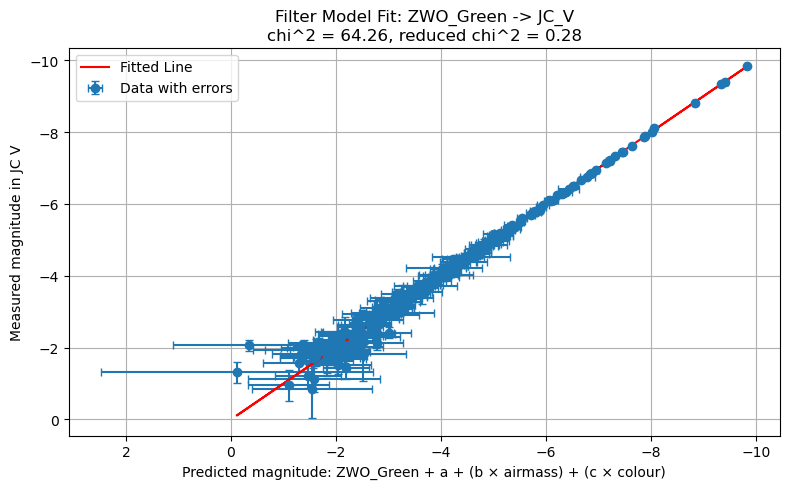

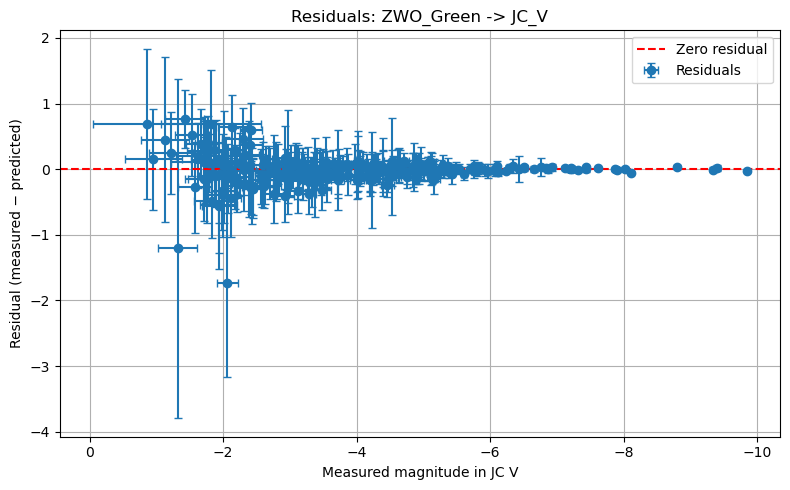

Fitted parameters:
a = -0.1672 ± 0.0396, b = 0.0274 ± 0.0288, c = -0.0920 ± 0.0379, chi^2 = 64.26, reduced chi^2 = 0.28



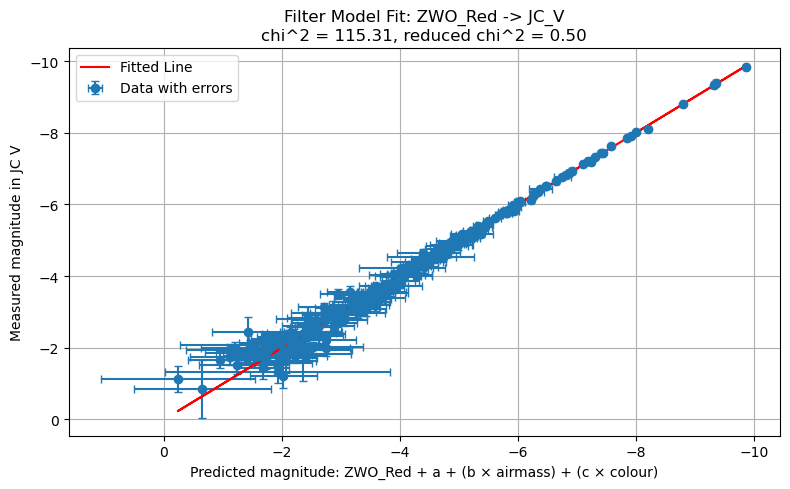

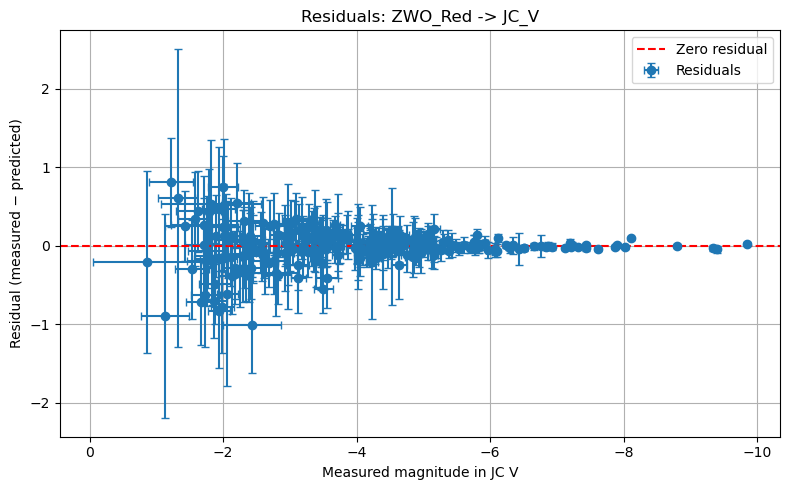

Fitted parameters:
a = -0.0043 ± 0.0424, b = -0.2691 ± 0.0311, c = 0.7780 ± 0.0402, chi^2 = 115.31, reduced chi^2 = 0.50



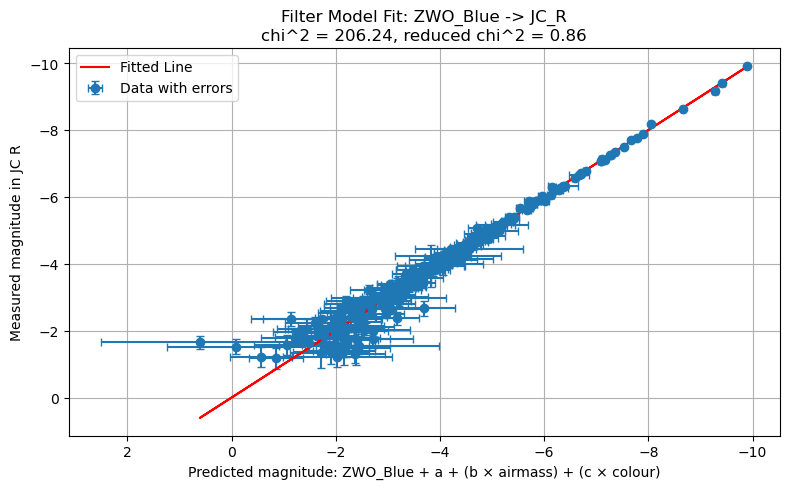

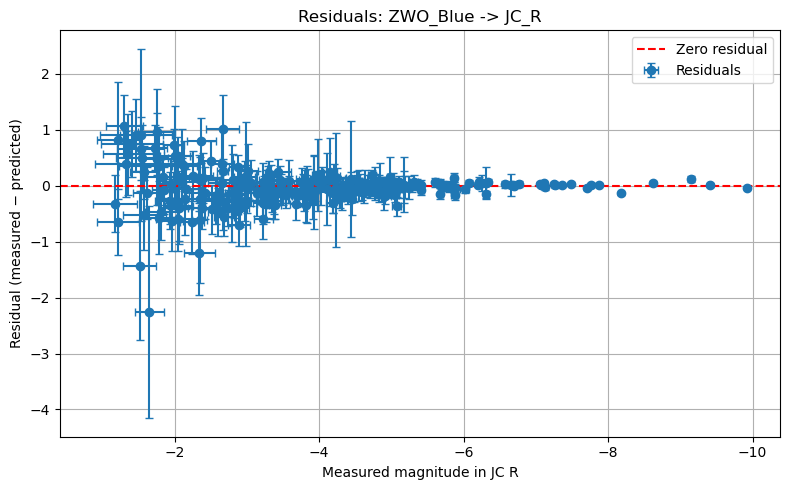

Fitted parameters:
a = -0.3117 ± 0.0445, b = 0.2954 ± 0.0334, c = -1.7940 ± 0.0410, chi^2 = 206.24, reduced chi^2 = 0.86



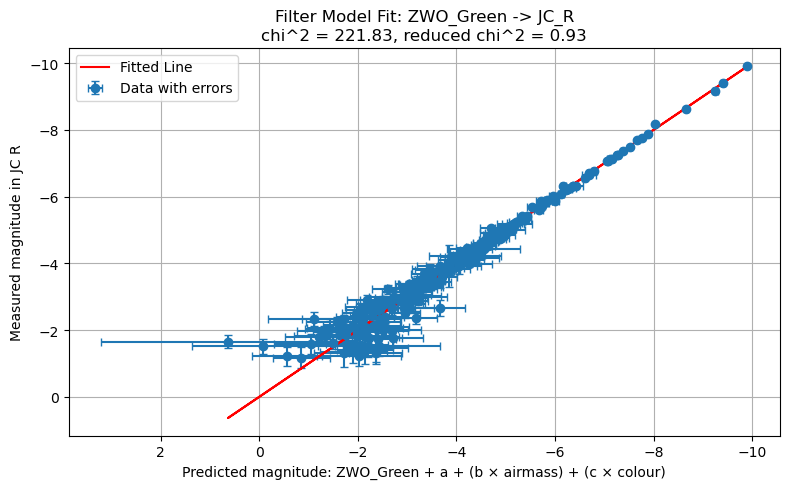

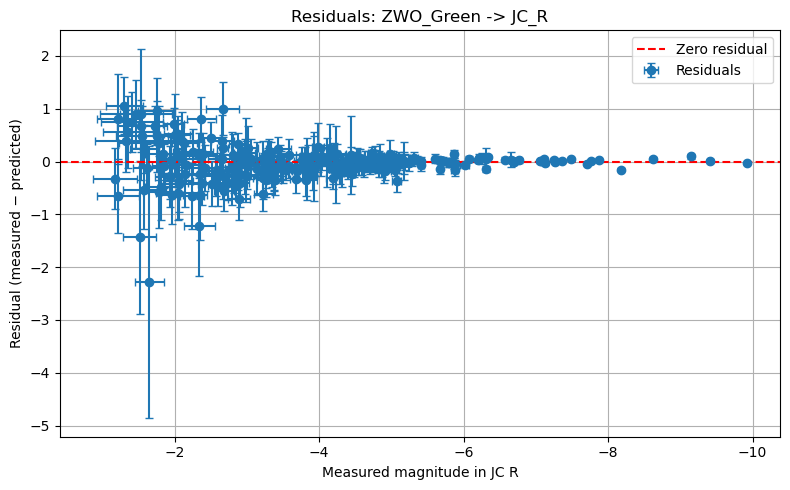

Fitted parameters:
a = -0.2624 ± 0.0396, b = 0.2542 ± 0.0286, c = -0.7941 ± 0.0386, chi^2 = 221.83, reduced chi^2 = 0.93



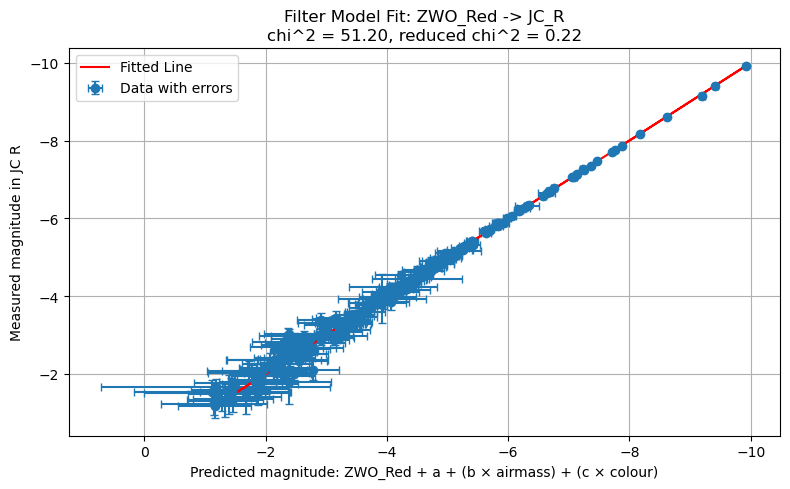

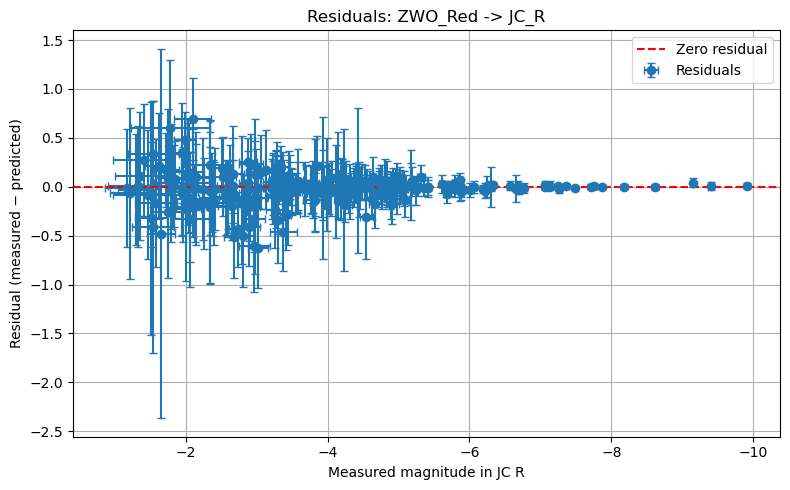

Fitted parameters:
a = -0.1240 ± 0.0423, b = -0.0204 ± 0.0309, c = 0.0494 ± 0.0404, chi^2 = 51.20, reduced chi^2 = 0.22



In [61]:
## dif colour calcs
stars = compute_colour(stars, 'ZWO_Blue', 'ZWO_Green')
#stars = compute_colour(stars, 'ZWO_Blue', 'ZWO_Red')
#stars = compute_colour(stars, 'ZWO_Green', 'ZWO_Red')

ZWO = ['ZWO_Blue', 'ZWO_Green', 'ZWO_Red']
JC = ['B', 'V', 'R']

# --- Loop through filters ---
transform_results = []
for filter_out in JC:
    for filter_in in ZWO:
        a, b, c, a_err, b_err, c_err, chi2, red_chi2 = filter_transform(filter_in, filter_out, plot=True)
        transform_results.append({
            "filter_from": filter_in, "filter_to": filter_out,
            "a": a, "a_err": a_err,
            "b": b, "b_err": b_err,
            "c": c, "c_err": c_err,
            "chi2": chi2,
            "reduced_chi2": red_chi2
        })

transform_df = pd.DataFrame(transform_results)
transform_df.to_csv("data/filter_transformations.csv", index=False)

# Conversion Factor check

In [52]:
# Load both standards files
files = ["Blue-Green_filter_transformations.csv", "Blue-Red_filter_transformations.csv", "Green-Red_filter_transformations.csv"]

filter_factors_dfs = []
for f in files:
    df = pd.read_csv(base_dir / f)
    colour = f.split("_")[0]
    df['colour'] = colour
    filter_factors_dfs.append(df)

# Concatenate
filter_factors = pd.concat(filter_factors_dfs, ignore_index=True)


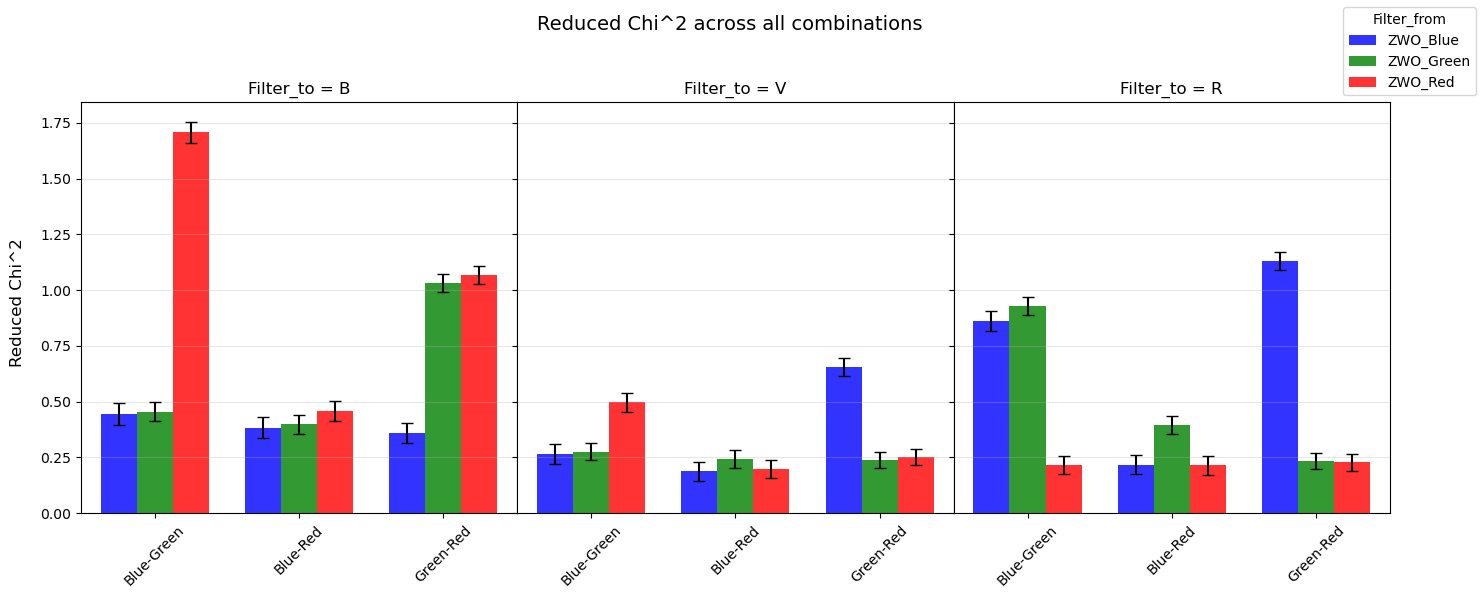

In [53]:
# --- Setup for faceted bar chart ---
filter_to_values = filter_factors['filter_to'].unique()
fig, axes = plt.subplots(1, len(filter_to_values), figsize=(15,6), sharey=True,
                         gridspec_kw={'wspace': 0})  # remove spacing between panels

width = 0.25
colours = filter_factors['colour'].unique()
filter_froms = filter_factors['filter_from'].unique()
x = np.arange(len(colours))

# Define colour mapping for filter_from
colour_map = {
    'ZWO_Blue': 'blue',
    'ZWO_Green': 'green',
    'ZWO_Red': 'red'
}

# --- Plot bars with error bars ---
for ax, filter_to in zip(axes, filter_to_values):
    subdf = filter_factors[filter_factors['filter_to'] == filter_to]

    for i, f_from in enumerate(filter_froms):
        df_plot = subdf[subdf['filter_from'] == f_from].set_index('colour').reindex(colours)
        heights = df_plot['reduced_chi2'].values
        errors = df_plot['a_err'].values  # or combine errors if needed

        ax.bar(x + i*width, heights, width,
               label=f_from,
               yerr=errors,
               capsize=4,
               alpha=0.8,
               color=colour_map.get(f_from, 'gray'))

    ax.set_xticks(x + width)
    ax.set_xticklabels(colours, rotation=45)
    ax.set_title(f"Filter_to = {filter_to}")
    ax.grid(axis='y', alpha=0.3)

"""
# --- Highlight best reduced χ² per colour group ---
for ax, filter_to in zip(axes, filter_to_values):
    subdf = filter_factors[filter_factors['filter_to'] == filter_to]
    for colour in colours:
        group = subdf[subdf['colour'] == colour]
        if not group.empty:
            best_row = group.loc[group['reduced_chi2'].idxmin()]
            f_from = best_row['filter_from']
            xpos = list(filter_froms).index(f_from)
            xval = x[list(colours).index(colour)] + xpos * width
            yval = best_row['reduced_chi2']

            ax.text(xval, yval + 0.05, "*",
                    ha='center', va='bottom',
                    fontsize=16, fontweight='bold',
                    color='black',
                    path_effects=[
                        path_effects.withStroke(linewidth=3, foreground='white')
                    ])
"""
# --- Shared y-axis label and single legend ---
fig.text(0.02, 0.5, "Reduced Chi^2", va='center', rotation='vertical', fontsize=12)
fig.suptitle("Reduced Chi^2 across all combinations", fontsize=14)

fig.legend(handles, labels, title="Filter_from", loc="upper right")

plt.tight_layout(rect=[0.03, 0, 0.95, 0.95])
plt.show()

In [54]:
filter_factors.to_csv("data/all_filter_transformations.csv", index=False)